In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/loan_risk_feature_engineered.csv")
df.head()

,Unnamed: 0,CustomerID,Age,Gender,MaritalStatus,Education,Occupation,EmploymentYears,AnnualIncome,MonthlyExpenses,...,FraudFlag,CustomerSegment,LoanApproved,MonthlyIncome,DisposableIncome,EMIRatio,SavingRatio,DebtToIncomeRatio,Networth,CreditUtilizationRatio
0,0,112424.0,36.0,Male,Single,PostGraduate,Salaried,25.0,6114208.0,190034.0,...,No,Regular,No,509517.333333,319483.333333,0.037881,0.751028,0.587899,7316519.0,0.192366
1,1,108271.0,25.0,Female,Single,HighSchool,SelfEmployed,30.0,4487423.0,24602.0,...,No,Regular,Yes,373951.916667,349349.916667,0.109621,1.979788,0.273935,13485542.0,0.085016
2,2,122724.0,32.0,Male,Single,Graduate,SelfEmployed,8.0,7493921.0,60028.0,...,No,Regular,Yes,624493.416667,564465.416667,0.078643,0.555598,0.495641,10186747.0,0.070233
3,3,112573.0,30.0,Female,Married,Graduate,Student,35.0,4152555.0,187520.0,...,No,Regular,Yes,346046.250000,158526.250000,0.163487,2.337600,0.611959,14080359.0,0.116370
4,4,112098.0,41.0,Female,Single,Graduate,Business,36.0,7929802.0,199257.0,...,No,Regular,No,660816.833333,461559.833333,0.075230,0.006726,0.238586,1209057.0,0.237283


In [3]:
df = df.drop(columns=["Unnamed: 0","CustomerID","FraudFlag","CustomerSegment"])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     25600 non-null  float64
 1   Gender                  25600 non-null  str    
 2   MaritalStatus           25600 non-null  str    
 3   Education               25600 non-null  str    
 4   Occupation              25600 non-null  str    
 5   EmploymentYears         25600 non-null  float64
 6   AnnualIncome            25600 non-null  float64
 7   MonthlyExpenses         25600 non-null  float64
 8   Savings                 25600 non-null  float64
 9   Investments             25600 non-null  float64
 10  ExistingLoans           25600 non-null  float64
 11  ExistingEMI             25600 non-null  float64
 12  LoanAmount              25600 non-null  float64
 13  LoanPurpose             25600 non-null  str    
 14  LoanTenure              25600 non-null  float64
 

In [5]:
label = LabelEncoder()

for col in df.select_dtypes(include=["object","string"]).columns:
    df[col] = label.fit_transform(df[col])

x = df.drop(columns=["LoanApproved"])
y = df["LoanApproved"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [6]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(random_state=42)
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.25,0.27,0.25,...,0.47,0.42,0.42]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.09,0.97,1.11,...,0.14,0.32,0.31]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](37,)","[0.,0.,0.,...,0.,0.,0.]"


In [7]:
y_pred = model.predict(x_test)

In [8]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[1337,    9],
       [  56, 3718]])

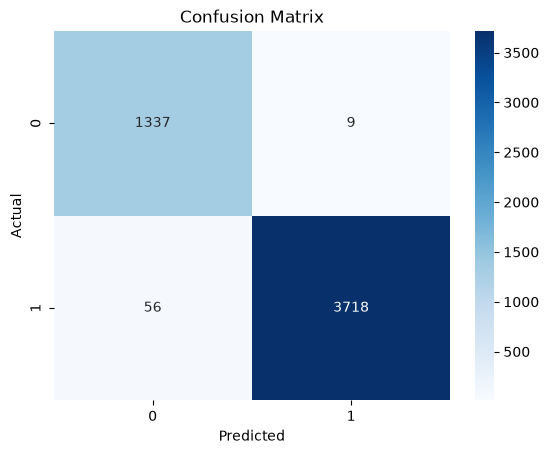

In [9]:
plt.Figure(figsize=(6,5))

sns.heatmap(cm,
            annot = True,
            fmt = "d",
            cmap = "Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

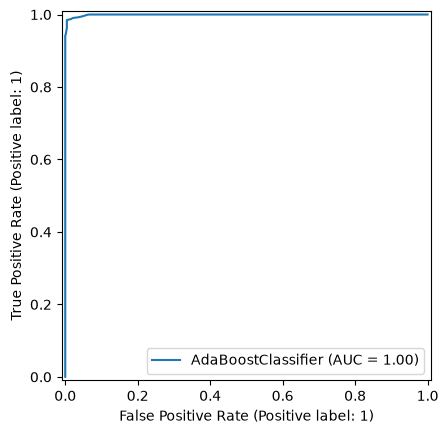

In [10]:
RocCurveDisplay.from_estimator(model,x_test,y_test)

plt.show()

In [11]:
prob = model.predict_proba(x_test)[:,1]

print(roc_auc_score(y_test,prob))

0.9993252692426716


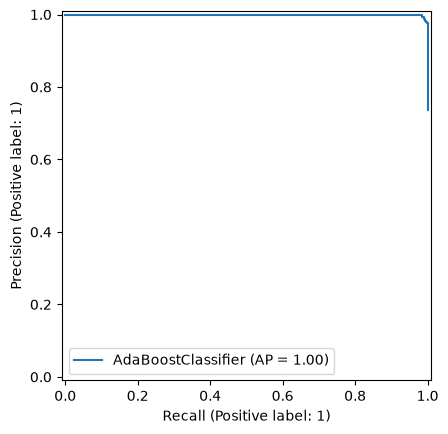

In [12]:
PrecisionRecallDisplay.from_estimator(model,x_test,y_test)

plt.show()

In [13]:
scores = cross_val_score(model,x,y,cv=5,scoring="accuracy")

print(scores)

print("Average Accuracy")
print(scores.mean())

[0.98574219 0.98769531 0.98671875 0.98632812 0.98671875]
Average Accuracy
0.9866406249999999


In [14]:
importance = pd.DataFrame({
    "Feature" : x.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(by = "Importance",
                                    ascending=False)
importance.head(15)

,Feature,Importance
23,MissedEMIs,0.224913
22,LatePayments,0.188875
15,CreditScore,0.184674
10,ExistingLoans,0.182479
30,MonthlyIncome,0.118376
6,AnnualIncome,0.100682
4,Occupation,0.000000
2,MaritalStatus,0.000000
1,Gender,0.000000
0,Age,0.000000


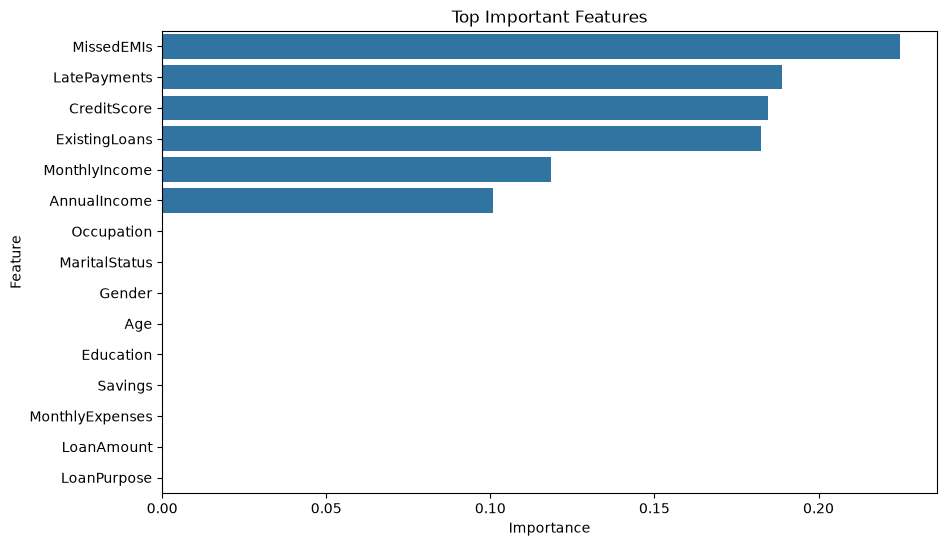

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data = importance.head(15),
    x = "Importance",
    y = "Feature"
)

plt.title("Top Important Features")

plt.show()